# Multimodal LoReFT Hyperparameter Sweep Visualization

This notebook visualizes and analyzes the results from hyperparameter sweeps to understand how different configurations affect model performance.

In [1]:
# Load the results from the sweeps (files in ./results/) and visualize performance over hyperparameters
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob
from IPython.display import display, HTML

# Set visualization style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context('notebook')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 14

## 1. Load and Prepare Data

First, let's load all the data files from the results directory. We expect to have separate files for training metrics, regression performance, and classification performance.

In [2]:
# Set the results directory path
results_dir = './results/staged_sweep_v1*2.csv'

# Find all CSV files in the results directory
csv_files = glob.glob(results_dir)
print(f"Found {len(csv_files)} CSV files in the results directory.")

# Group files by type (train, regression, classification)
train_files = [f for f in csv_files if 'train' in f.lower()]
regression_files = [f for f in csv_files if 'regression' in f.lower()]
classification_files = [f for f in csv_files if 'classification' in f.lower()]
#rank_files = [f for f in csv_files if 'rank' in f.lower()]
rank_files = [f for f in csv_files if 'analysis' in f.lower()]

print(f"Train files: {len(train_files)}")
print(f"Regression files: {len(regression_files)}")
print(f"Classification files: {len(classification_files)}")
print(f"Rank files: {len(rank_files)}")

Found 9 CSV files in the results directory.
Train files: 0
Regression files: 3
Classification files: 3
Rank files: 3


In [3]:
# Load all the regression data
regression_dfs = []
for file in regression_files:
    df = pd.read_csv(file)
    # Add filename as a column for tracking
    df['source_file'] = os.path.basename(file)
    regression_dfs.append(df)

# Combine all regression data
if regression_dfs:
    regression_df = pd.concat(regression_dfs, ignore_index=True)
    print(f"Loaded regression data: {regression_df.shape[0]} rows, {regression_df.shape[1]} columns")
    display(regression_df.head())
else:
    regression_df = None
    print("No regression data found.")

Loaded regression data: 864 rows, 12 columns


,name,r2_mean,r2_std,batch_size,learning_rate,lr_annealing,weight_decay,specific_rank,shared_rank,patience1,patience2,source_file
0,Zm1,0.443628,0.274449,64,0.001,cosine,0.0001,4,4,20,50,staged_sweep_v1_seed0_sim_100000_in5-5_data5-5...
1,Zs1,0.771137,0.123750,64,0.001,cosine,0.0001,4,4,20,50,staged_sweep_v1_seed0_sim_100000_in5-5_data5-5...
2,(Zm+Zs)1,0.749163,0.279857,64,0.001,cosine,0.0001,4,4,20,50,staged_sweep_v1_seed0_sim_100000_in5-5_data5-5...
3,Zm2,0.636464,0.242362,64,0.001,cosine,0.0001,4,4,20,50,staged_sweep_v1_seed0_sim_100000_in5-5_data5-5...
4,Zs2,0.876082,0.034245,64,0.001,cosine,0.0001,4,4,20,50,staged_sweep_v1_seed0_sim_100000_in5-5_data5-5...


In [4]:
# Load all the classification data
classification_dfs = []
for file in classification_files:
    df = pd.read_csv(file)
    # Add filename as a column for tracking
    df['source_file'] = os.path.basename(file)
    classification_dfs.append(df)

# Combine all classification data
if classification_dfs:
    classification_df = pd.concat(classification_dfs, ignore_index=True)
    print(f"Loaded classification data: {classification_df.shape[0]} rows, {classification_df.shape[1]} columns")
    display(classification_df.head())
else:
    classification_df = None
    print("No classification data found.")

Loaded classification data: 576 rows, 15 columns


,name,accuracy,precision,recall,f1,roc_auc,batch_size,learning_rate,lr_annealing,weight_decay,specific_rank,shared_rank,patience1,patience2,source_file
0,Zs1,1.000000,1.0,1.000000,1.0000,1.000000,64,0.001,cosine,0.0001,4,4,20,50,staged_sweep_v1_seed0_sim_100000_in5-5_data5-5...
1,Zs2,1.000000,1.0,1.000000,1.0000,1.000000,64,0.001,cosine,0.0001,4,4,20,50,staged_sweep_v1_seed0_sim_100000_in5-5_data5-5...
2,Zm1,1.000000,1.0,1.000000,1.0000,1.000000,64,0.001,cosine,0.0001,4,4,20,50,staged_sweep_v1_seed0_sim_100000_in5-5_data5-5...
3,Zm2,0.998333,1.0,0.996825,0.9984,0.998413,64,0.001,cosine,0.0001,4,4,20,50,staged_sweep_v1_seed0_sim_100000_in5-5_data5-5...
4,Zs1,1.000000,1.0,1.000000,1.0000,1.000000,64,0.001,cosine,0.0000,4,4,20,50,staged_sweep_v1_seed0_sim_100000_in5-5_data5-5...


In [5]:
# same for rank
rank_dfs = []
for file in rank_files:
    df = pd.read_csv(file)
    # Add filename as a column for tracking
    df['source_file'] = os.path.basename(file)
    rank_dfs.append(df)

# Combine all rank data
if rank_dfs:
    rank_df = pd.concat(rank_dfs, ignore_index=True)
    print(f"Loaded rank data: {rank_df.shape[0]} rows, {rank_df.shape[1]} columns")
    display(rank_df.head())
else:
    rank_df = None
    print("No rank data found.")

Loaded rank data: 864 rows, 12 columns


,name,metric,value,batch_size,learning_rate,lr_annealing,weight_decay,specific_rank,shared_rank,patience1,patience2,source_file
0,R_s-R_m1,correlation,0.160436,64,0.001,cosine,0.0001,4,4,20,50,staged_sweep_v1_seed0_sim_100000_in5-5_data5-5...
1,R_s-R_m2,correlation,-0.040251,64,0.001,cosine,0.0001,4,4,20,50,staged_sweep_v1_seed0_sim_100000_in5-5_data5-5...
2,R_m1-R_m2,correlation,0.151311,64,0.001,cosine,0.0001,4,4,20,50,staged_sweep_v1_seed0_sim_100000_in5-5_data5-5...
3,R_s,rank,3.000000,64,0.001,cosine,0.0001,4,4,20,50,staged_sweep_v1_seed0_sim_100000_in5-5_data5-5...
4,R_m1,rank,1.000000,64,0.001,cosine,0.0001,4,4,20,50,staged_sweep_v1_seed0_sim_100000_in5-5_data5-5...


## 2. Data Exploration and Statistics

Let's explore the data to understand the hyperparameter space and distribution of performance metrics.

In [6]:
# Get unique hyperparameter values
hyperparams = ['batch_size', 'learning_rate', 'lr_annealing', 'weight_decay', 'specific_rank', 'shared_rank']
def explore_hyperparameters(df):
    if df is None:
        return
    for param in hyperparams:
        if param in df.columns:
            unique_values = df[param].unique()
            print(f"{param}: {unique_values}")

print("Regression hyperparameters:")
explore_hyperparameters(regression_df)
print("\nClassification hyperparameters:")
explore_hyperparameters(classification_df)

Regression hyperparameters:
batch_size: [ 64 128 256 512]
learning_rate: [1.e-03 1.e-04 1.e-05]
lr_annealing: ['cosine' 'constant']
weight_decay: [0.0001 0.    ]
specific_rank: [4]
shared_rank: [4]

Classification hyperparameters:
batch_size: [ 64 128 256 512]
learning_rate: [1.e-03 1.e-04 1.e-05]
lr_annealing: ['cosine' 'constant']
weight_decay: [0.0001 0.    ]
specific_rank: [4]
shared_rank: [4]


## 3. Visualize Regression Performance

Let's create visualizations to understand how different hyperparameters affect regression performance.

In [7]:
def plot_score_by_hyperparam(df, param, metric='r2_mean', metric_type='column'):
    if df is None:
        print("No data available.")
        return
    
    if param not in df.columns or (metric not in df.columns and metric_type == 'column'):
        print(f"Either {param} or {metric} not found in data.")
        return
    elif param not in df.columns or (metric_type == 'value' and metric not in df['metric'].values):
        print(f"Either {param} or {metric} not found in data.")
        return
    elif metric_type not in ['column', 'value']:
        print(f"Invalid metric type: {metric_type}. Use 'column' or 'value'.")
        return
    
    # Check if there's more than one unique value for this hyperparameter
    unique_values = df[param].unique()
    if len(unique_values) <= 1:
        print(f"Skipping plots for {param} because there is only one unique value: {unique_values}")
        return
    
    # Create one bar plot for component performances grouped by the hyperparameter
    plt.figure(figsize=(8, 3))
    
    if metric_type == 'column':
        sns.barplot(x='name', y=metric, hue=param, data=df,
                    ci='sd', palette='muted', capsize=0.1, alpha=0.8)
        # set y limits to min and max of the metric
        #plt.ylim(df[metric].min() - 0.1, df[metric].max() + 0.1)
    else:
        df = df[df['metric'] == metric]
        sns.barplot(x='name', y='value', hue=param, data=df,
                    ci='sd', palette='muted', capsize=0.1, alpha=0.8)
        # set y limits to min and max of the metric
        #plt.ylim(df['value'].min() - 0.1, df['value'].max() + 0.1)
    
    plt.title(f'Average Score by {param}')
    plt.ylabel(f'Score ({metric})')
    plt.xlabel('Representation Component')
    plt.xticks(rotation=45)
    plt.legend(title=param, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

/tmp/ipykernel_695451/543427899.py:6: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(x='name', y='r2_mean', data=regression_df, ci='sd', palette='muted', capsize=0.1, alpha=0.8)
/tmp/ipykernel_695451/543427899.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='name', y='r2_mean', data=regression_df, ci='sd', palette='muted', capsize=0.1, alpha=0.8)


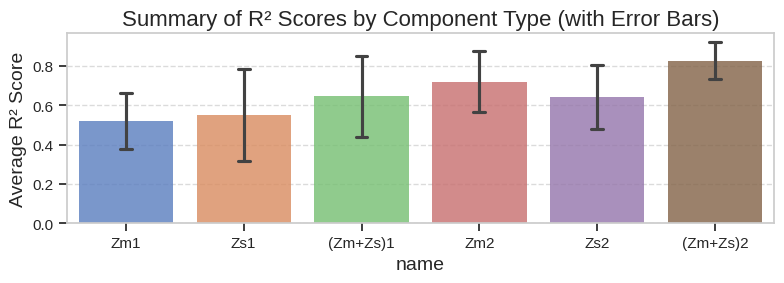

/tmp/ipykernel_695451/4145973188.py:26: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(x='name', y=metric, hue=param, data=df,


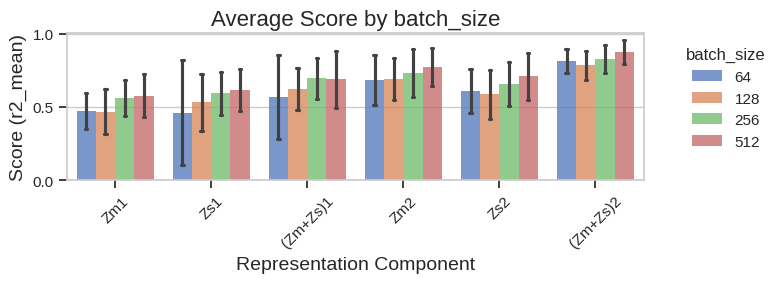

/tmp/ipykernel_695451/4145973188.py:26: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(x='name', y=metric, hue=param, data=df,


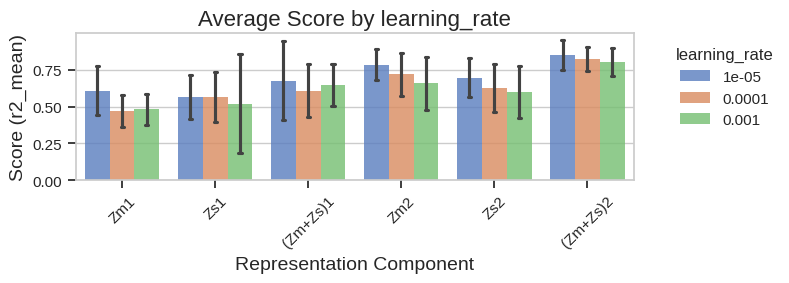

/tmp/ipykernel_695451/4145973188.py:26: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(x='name', y=metric, hue=param, data=df,


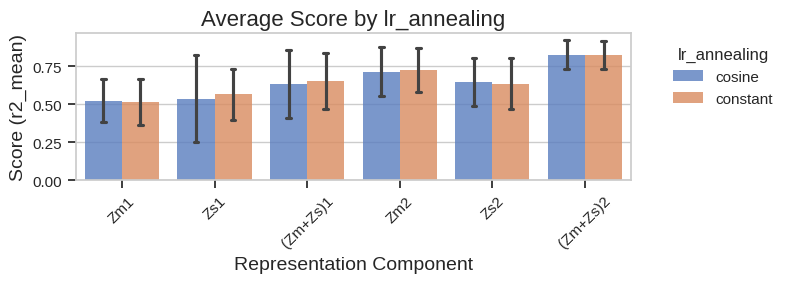

/tmp/ipykernel_695451/4145973188.py:26: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(x='name', y=metric, hue=param, data=df,


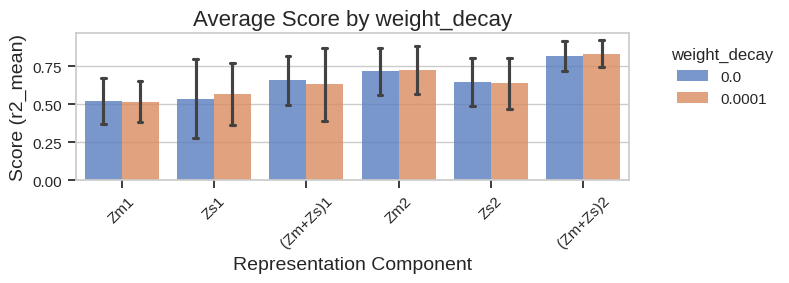

Skipping plots for specific_rank because there is only one unique value: [4]
Skipping plots for shared_rank because there is only one unique value: [4]


In [8]:
# Visualize regression performance by hyperparameters
# First, create a summary bar plot of R2 scores by component type with error bars
if regression_df is not None and 'r2_mean' in regression_df.columns and 'r2_std' in regression_df.columns:
    plt.figure(figsize=(8, 3))
    
    sns.barplot(x='name', y='r2_mean', data=regression_df, ci='sd', palette='muted', capsize=0.1, alpha=0.8)
    
    plt.title('Summary of R² Scores by Component Type (with Error Bars)')
    plt.ylabel('Average R² Score')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

# Plot for each hyperparameter with multiple unique values
hyperparams = ['batch_size', 'learning_rate', 'lr_annealing', 'weight_decay', 'specific_rank', 'shared_rank']
for param in hyperparams:
    plot_score_by_hyperparam(regression_df, param)

## 4. Visualize Classification Performance

Now let's explore how hyperparameters affect classification performance.

/tmp/ipykernel_695451/1252302570.py:18: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(x='name', y=metric, data=classification_df, ci='sd', palette='muted', capsize=0.1, alpha=0.8)
/tmp/ipykernel_695451/1252302570.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='name', y=metric, data=classification_df, ci='sd', palette='muted', capsize=0.1, alpha=0.8)


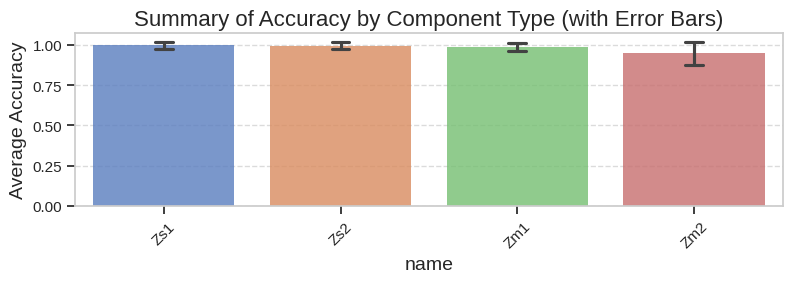


Summary of Accuracy by Component:
Zs1: 0.9967 ± 0.0197
Zs2: 0.9958 ± 0.0189
Zm1: 0.9867 ± 0.0236
Zm2: 0.9475 ± 0.0729


/tmp/ipykernel_695451/4145973188.py:26: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(x='name', y=metric, hue=param, data=df,


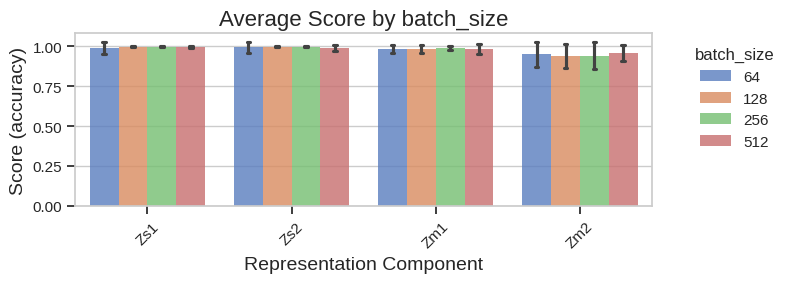

/tmp/ipykernel_695451/4145973188.py:26: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(x='name', y=metric, hue=param, data=df,


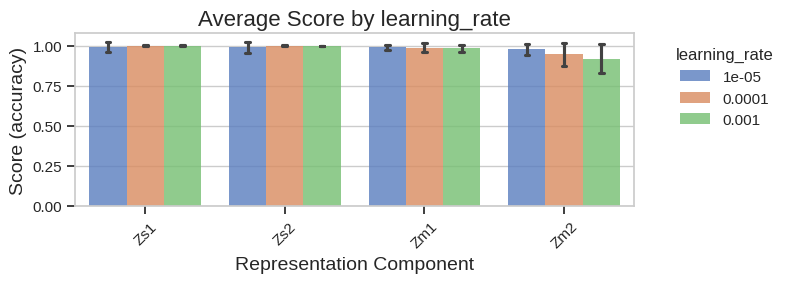

/tmp/ipykernel_695451/4145973188.py:26: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(x='name', y=metric, hue=param, data=df,


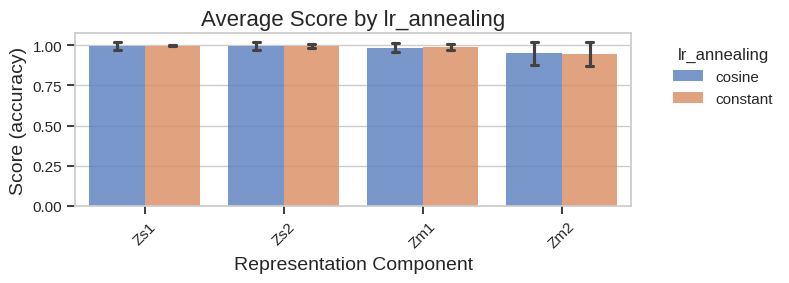

/tmp/ipykernel_695451/4145973188.py:26: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(x='name', y=metric, hue=param, data=df,


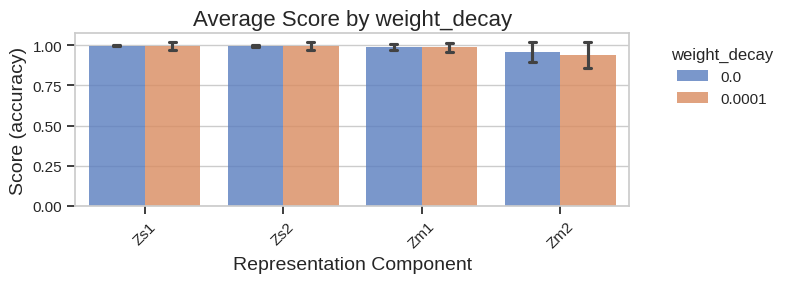

Skipping plots for specific_rank because there is only one unique value: [4]
Skipping plots for shared_rank because there is only one unique value: [4]


In [11]:
# Visualize classification performance by hyperparameters

# Create a summary bar plot of classification metrics by component type with error bars
if classification_df is not None:
    #metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
    metrics = ['accuracy']
    available_metrics = [m for m in metrics if m in classification_df.columns]
    
    for metric in available_metrics:
        plt.figure(figsize=(8, 3))
        
        # Group by component name and compute mean and std
        summary_data = classification_df.groupby('name')[metric].agg(['mean', 'std']).reset_index()
        
        # Sort by mean score for better visualization
        summary_data = summary_data.sort_values('mean', ascending=False)
        
        sns.barplot(x='name', y=metric, data=classification_df, ci='sd', palette='muted', capsize=0.1, alpha=0.8)
        
        plt.title(f'Summary of {metric.capitalize()} by Component Type (with Error Bars)')
        plt.ylabel(f'Average {metric.capitalize()}')
        plt.xticks(range(len(summary_data)), summary_data['name'], rotation=45)
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()
        
        # Print numerical summary
        print(f"\nSummary of {metric.capitalize()} by Component:")
        for idx, row in summary_data.iterrows():
            print(f"{row['name']}: {row['mean']:.4f} ± {row['std']:.4f}")

# Plot for each hyperparameter with multiple unique values
hyperparams = ['batch_size', 'learning_rate', 'lr_annealing', 'weight_decay', 'specific_rank', 'shared_rank']
for param in hyperparams:
    plot_score_by_hyperparam(classification_df, param, metric='accuracy')

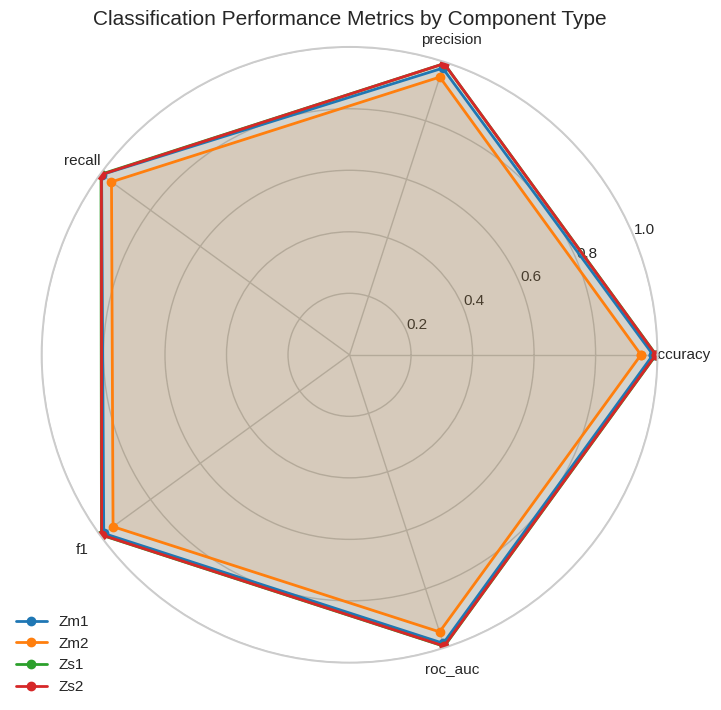

In [12]:
# Create radar plot for comparing components
if classification_df is not None:
    metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
    available_metrics = [m for m in metrics if m in classification_df.columns]
    
    if available_metrics:
        # Prepare data by averaging across hyperparameters for each component
        component_metrics = classification_df.groupby('name')[available_metrics].mean().reset_index()
        
        # Number of metrics we're plotting
        N = len(available_metrics)
        
        # Create radar plot
        plt.figure(figsize=(10, 8))
        
        # Create angles for each metric
        angles = np.linspace(0, 2*np.pi, N, endpoint=False)
        
        # The plot is circular, so we need to close the loop
        angles = np.concatenate((angles, [angles[0]]))
        
        # Create plot
        ax = plt.subplot(111, polar=True)
        
        # Add each component
        for idx, row in component_metrics.iterrows():
            values = row[available_metrics].values.tolist()
            values = np.concatenate((values, [values[0]]))
            ax.plot(angles, values, 'o-', linewidth=2, label=row['name'])
            ax.fill(angles, values, alpha=0.1)
        
        # Set labels and title
        plt.xticks(angles[:-1], available_metrics)
        plt.title('Classification Performance Metrics by Component Type', size=15)
        plt.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))
        
        plt.show()
    else:
        print("No classification metrics available for radar plot.")
else:
    print("No classification data available for radar plot.")

## 5. R Matrix correlation and ranks

/tmp/ipykernel_695451/4145973188.py:32: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(x='name', y='value', hue=param, data=df,


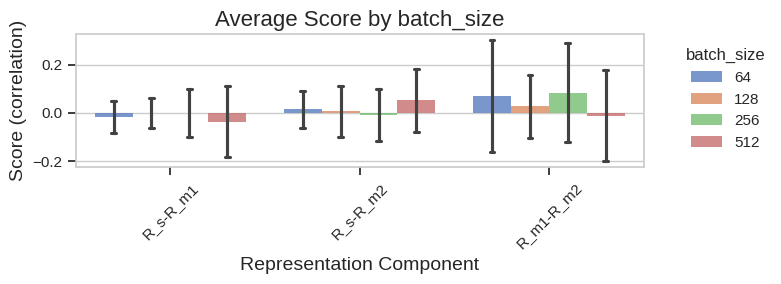

/tmp/ipykernel_695451/4145973188.py:32: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(x='name', y='value', hue=param, data=df,


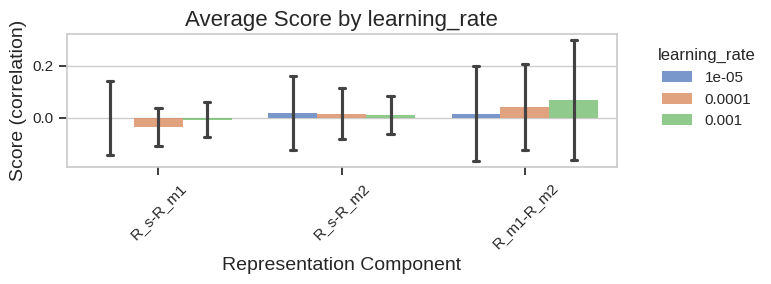

/tmp/ipykernel_695451/4145973188.py:32: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(x='name', y='value', hue=param, data=df,


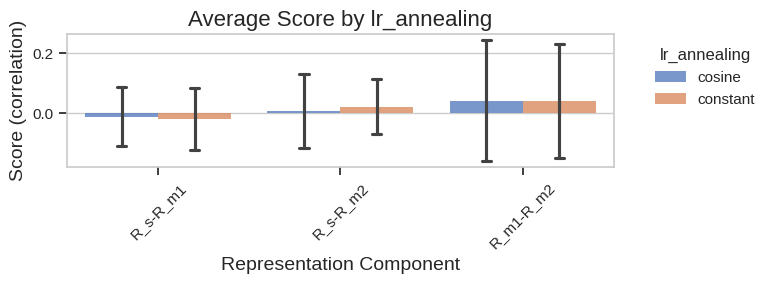

/tmp/ipykernel_695451/4145973188.py:32: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(x='name', y='value', hue=param, data=df,


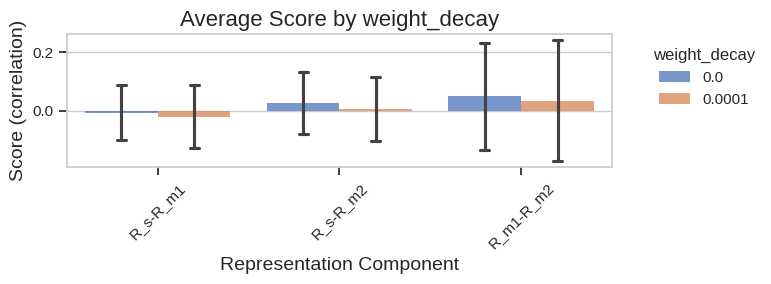

Skipping plots for specific_rank because there is only one unique value: [4]
Skipping plots for shared_rank because there is only one unique value: [4]


In [13]:
for param in hyperparams:
    plot_score_by_hyperparam(rank_df, param, metric='correlation', metric_type='value')

/tmp/ipykernel_695823/4145973188.py:32: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(x='name', y='value', hue=param, data=df,


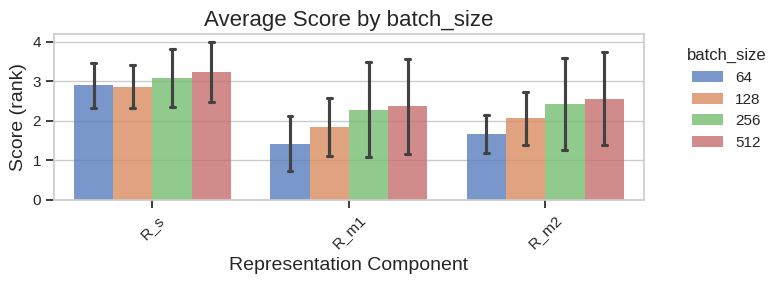

/tmp/ipykernel_695823/4145973188.py:32: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(x='name', y='value', hue=param, data=df,


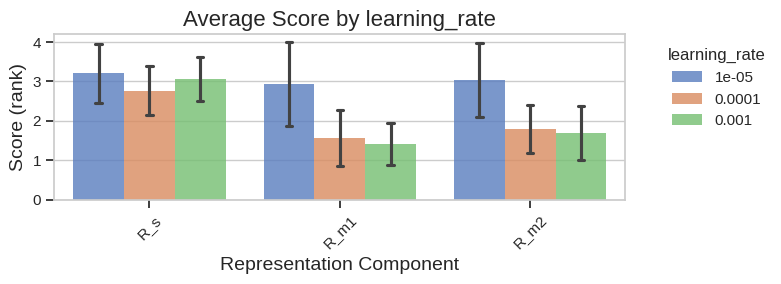

/tmp/ipykernel_695823/4145973188.py:32: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(x='name', y='value', hue=param, data=df,


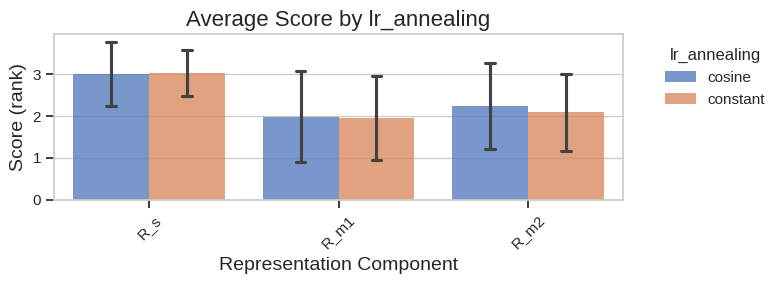

/tmp/ipykernel_695823/4145973188.py:32: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(x='name', y='value', hue=param, data=df,


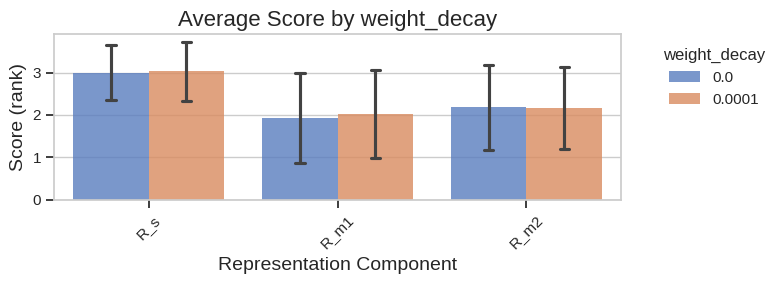

Skipping plots for specific_rank because there is only one unique value: [4]
Skipping plots for shared_rank because there is only one unique value: [4]


In [13]:
for param in hyperparams:
    plot_score_by_hyperparam(rank_df, param, metric='rank', metric_type='value')

## 6. learning curves

In [58]:
# Set the results directory path
results_dir = './results/staged_sweep_v1*train.csv'

# Find all CSV files in the results directory
csv_files = glob.glob(results_dir)
print(f"Found {len(csv_files)} CSV files in the results directory.")

# Group files by type (train, regression, classification)
train_files = [f for f in csv_files if 'train' in f.lower()]

print(f"Train files: {len(train_files)}")

train_dfs = []
for file in train_files:
    df = pd.read_csv(file)
    # Add filename as a column for tracking
    df['source_file'] = os.path.basename(file)
    df['seed'] = file.split('_seed')[-1].split('_')[0]
    train_dfs.append(df)
# Combine all train data
if train_dfs:
    train_df = pd.concat(train_dfs, ignore_index=True)
    print(f"Loaded train data: {train_df.shape[0]} rows, {train_df.shape[1]} columns")
    cols_for_name = ['batch_size', 'learning_rate', 'lr_annealing', 'weight_decay', 'specific_rank', 'shared_rank', 'seed']
    train_df['model_name'] = train_df[cols_for_name].astype(str).agg('-'.join, axis=1)
else:
    train_df = None
    print("No train data found.")

# epochs are missing
# add epochs as ranges from 0 for every subset of unique source_file
def add_epochs(df):
    if df is None:
        return
    df_out = []
    unique_files = df['model_name'].unique()
    for file in unique_files:
        file_df = df[df['model_name'] == file]  # Update to filter by 'model_name'
        # Create a new column 'epoch' and set it to the range of unique model_name
        file_df['epoch'] = np.arange(len(file_df))
        df_out.append(file_df)
    df_out = pd.concat(df_out, ignore_index=True)
    df_out['epoch'] = df_out['epoch'] + 1
    return df_out
train_df = add_epochs(train_df)
display(train_df.head())

Found 3 CSV files in the results directory.
Train files: 3
Loaded train data: 155699 rows, 15 columns


/tmp/ipykernel_695823/170238796.py:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  file_df['epoch'] = np.arange(len(file_df))
/tmp/ipykernel_695823/170238796.py:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  file_df['epoch'] = np.arange(len(file_df))
/tmp/ipykernel_695823/170238796.py:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pand

,Shared Loss,Orthogonal Loss,Mutual Info Loss,lr,stage,batch_size,learning_rate,lr_annealing,weight_decay,specific_rank,shared_rank,patience1,patience2,source_file,seed,model_name,epoch
0,0.276054,18.065078,4.164581,0.001,shared,64,0.001,cosine,0.0001,4,4,20,50,staged_sweep_v1_seed346_sim_100000_in5-5_data5...,346,64-0.001-cosine-0.0001-4-4-346,1
1,-0.136959,18.080130,4.043195,0.001,shared,64,0.001,cosine,0.0001,4,4,20,50,staged_sweep_v1_seed346_sim_100000_in5-5_data5...,346,64-0.001-cosine-0.0001-4-4-346,2
2,-0.677377,18.398965,3.933883,0.001,shared,64,0.001,cosine,0.0001,4,4,20,50,staged_sweep_v1_seed346_sim_100000_in5-5_data5...,346,64-0.001-cosine-0.0001-4-4-346,3
3,-0.895068,19.124949,3.842722,0.001,shared,64,0.001,cosine,0.0001,4,4,20,50,staged_sweep_v1_seed346_sim_100000_in5-5_data5...,346,64-0.001-cosine-0.0001-4-4-346,4
4,-0.945114,19.758275,3.779826,0.001,shared,64,0.001,cosine,0.0001,4,4,20,50,staged_sweep_v1_seed346_sim_100000_in5-5_data5...,346,64-0.001-cosine-0.0001-4-4-346,5


/tmp/ipykernel_695823/3825410610.py:7: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.lineplot(data=train_df, x='epoch', y=loss_columns[i], ax=axs[j, i], hue=hyperparams[j], palette='muted', ci='sd')
/tmp/ipykernel_695823/3825410610.py:7: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.lineplot(data=train_df, x='epoch', y=loss_columns[i], ax=axs[j, i], hue=hyperparams[j], palette='muted', ci='sd')
/tmp/ipykernel_695823/3825410610.py:7: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.lineplot(data=train_df, x='epoch', y=loss_columns[i], ax=axs[j, i], hue=hyperparams[j], palette='muted', ci='sd')
/tmp/ipykernel_695823/3825410610.py:7: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.lineplot(data=train_df, x='epoch', y=loss_columns[i], ax=axs[j, i], hue=hyperparams[j], palette='muted', c

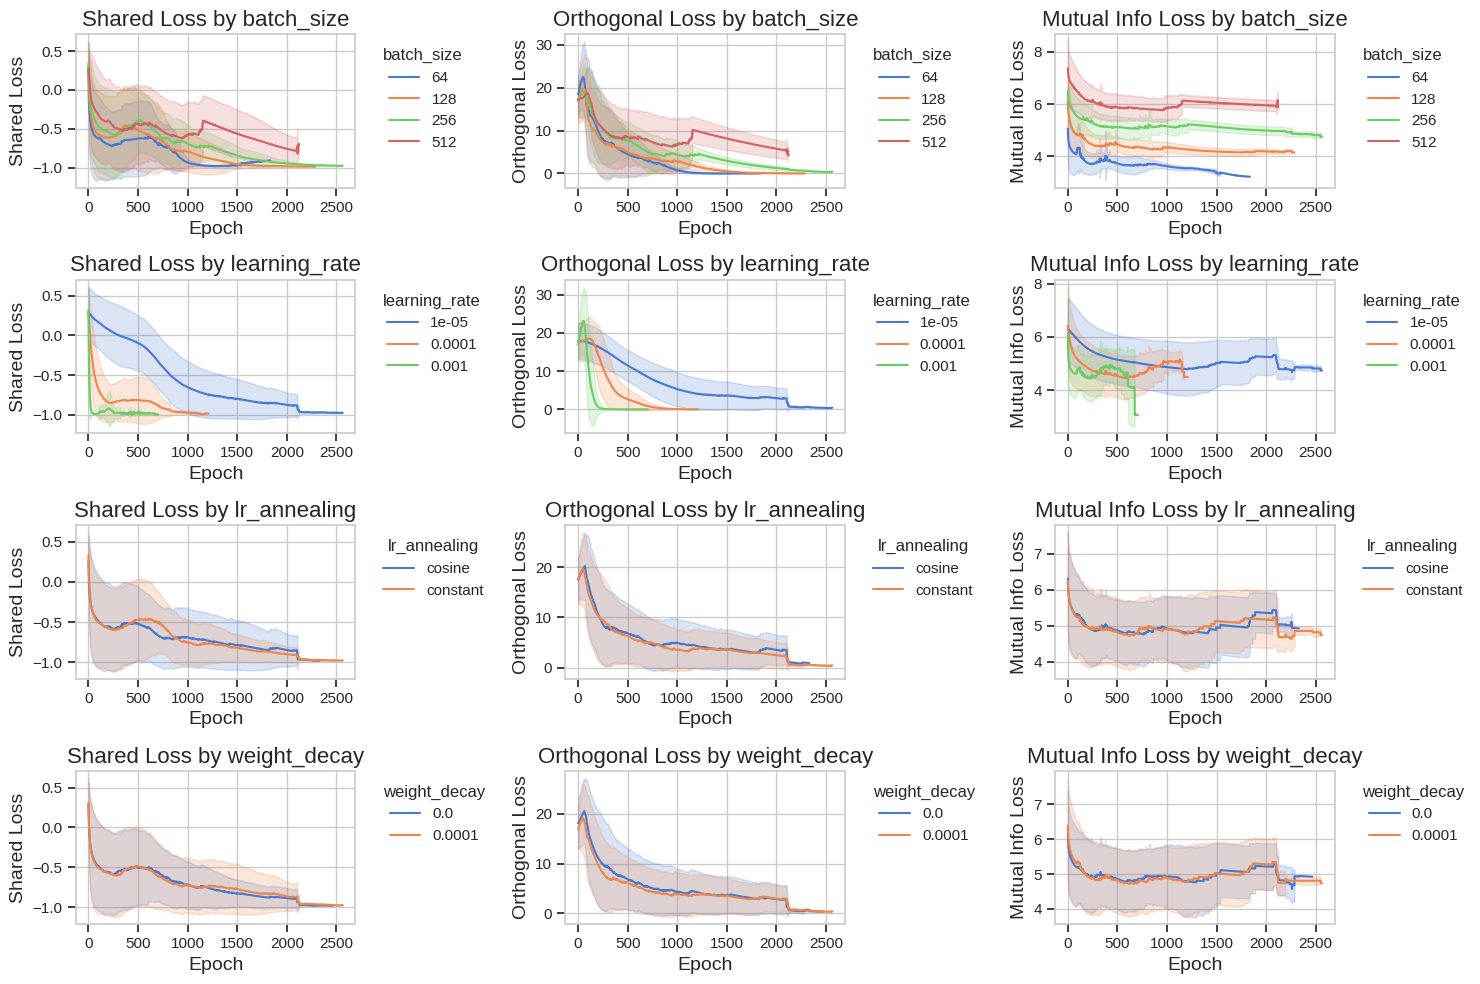

In [60]:
hyperparams = ['batch_size', 'learning_rate', 'lr_annealing', 'weight_decay']
fig, axs = plt.subplots(len(hyperparams), 3, figsize=(15,10))

loss_columns = ['Shared Loss', 'Orthogonal Loss', 'Mutual Info Loss']
for i in range(len(loss_columns)):
    for j in range(len(hyperparams)):
        sns.lineplot(data=train_df, x='epoch', y=loss_columns[i], ax=axs[j, i], hue=hyperparams[j], palette='muted', ci='sd')
        axs[j, i].set_title(f'{loss_columns[i]} by {hyperparams[j]}')
        axs[j, i].set_xlabel('Epoch')
        axs[j, i].set_ylabel(loss_columns[i])
        axs[j, i].legend(title=hyperparams[j], bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Find best model

Find the best model based on best regression performance on (Zs+Zm), classification performance on Zs, lowest mean correlation between the Rs, and large difference between Zs and Zm classification accuracy.
Rank all models for each task. Find the best model for each task and the best model overall.

In [8]:
# Implement functions to find the best model based on different criteria
def find_best_regression_models(reg_df):
    # Filter for (Zm+Zs) components
    combined_df = reg_df[reg_df['name'].str.contains('\(Zm\+Zs\)')].copy()
    
    # First group by hyperparameters and name to get performance for each component type
    group_cols = ['batch_size', 'learning_rate', 'lr_annealing', 'weight_decay', 'specific_rank', 'shared_rank']
    # Group by hyperparameters and compute the mean across seeds for each component (Zm+Zs)1 and (Zm+Zs)2
    component_means = combined_df.groupby(group_cols + ['name'])['r2_mean'].mean().reset_index() # I checked and it is correctly computed
    
    # Now get the average performance across both components for each hyperparameter set
    reg_ranks = component_means.groupby(group_cols)['r2_mean'].mean().reset_index()
    
    # Rank models (higher r2_mean is better)
    reg_ranks['rank'] = reg_ranks['r2_mean'].rank(ascending=False)
    
    return reg_ranks.sort_values('rank')

def find_best_classification_models(cls_df):
    # Filter for Zs components
    # make sure that Zm is not included
    zs_df = cls_df[~cls_df['name'].str.contains('Zm')].copy()
    #zs_df = cls_df[cls_df['name'].str.contains('Zs')].copy()
    
    # Group by hyperparameters to get average performance across components and seeds
    group_cols = ['batch_size', 'learning_rate', 'lr_annealing', 'weight_decay', 'specific_rank', 'shared_rank']
    cls_ranks = zs_df.groupby(group_cols + ['name'])['accuracy'].mean().reset_index()
    cls_ranks = cls_ranks.groupby(group_cols)['accuracy'].mean().reset_index()
    
    # Rank models (higher accuracy is better)
    cls_ranks['rank'] = cls_ranks['accuracy'].rank(ascending=False)
    
    return cls_ranks.sort_values('rank')

def find_best_correlation_models(corr_df):
    # Filter for correlation metrics
    corr_metrics = corr_df[corr_df['metric'] == 'correlation'].copy()
    
    # Calculate the absolute value of correlations
    corr_metrics['abs_corr'] = corr_metrics['value'].abs()
    
    # Group by hyperparameters to get average absolute correlation across Rs
    group_cols = ['batch_size', 'learning_rate', 'lr_annealing', 'weight_decay', 'specific_rank', 'shared_rank']
    corr_ranks = corr_metrics.groupby(group_cols)['abs_corr'].mean().reset_index() # actually I guess it is the exact same
    
    # Rank models (lower correlation is better)
    corr_ranks['rank'] = corr_ranks['abs_corr'].rank(ascending=True)
    
    return corr_ranks.sort_values('rank')

def find_best_rank_models(rank_df):
    # Filter for rank metrics
    rank_metrics = rank_df[rank_df['metric'] == 'rank'].copy()
    rank_metrics['matrix rank'] = rank_metrics['value'].abs()
    
    # Group by hyperparameters to get average rank across components
    group_cols = ['batch_size', 'learning_rate', 'lr_annealing', 'weight_decay', 'specific_rank', 'shared_rank']
    rank_ranks = rank_metrics.groupby(group_cols)['matrix rank'].mean().reset_index()
    
    # Rank models (lower rank is better)
    rank_ranks['rank'] = rank_ranks['matrix rank'].rank(ascending=True)
    
    return rank_ranks.sort_values('rank')

def find_best_accuracy_diff_models(cls_df):
    # Calculate average accuracy for Zs and Zm components for each hyperparameter combination
    group_cols = ['batch_size', 'learning_rate', 'lr_annealing', 'weight_decay', 'specific_rank', 'shared_rank']
    
    # Filter for Zs components and calculate mean accuracy
    zs_accuracy = cls_df[cls_df['name'].str.contains('Zs')].groupby(group_cols + ['name'])['accuracy'].mean().reset_index()
    zs_accuracy = zs_accuracy.rename(columns={'accuracy': 'zs_accuracy'})
    # change the name values from Zs1 and Zs2 to 1 and 2
    zs_accuracy['name'] = zs_accuracy['name'].str.replace('Zs', '')
    
    # Filter for Zm components and calculate mean accuracy
    zm_accuracy = cls_df[cls_df['name'].str.contains('Zm')].groupby(group_cols + ['name'])['accuracy'].mean().reset_index()
    zm_accuracy = zm_accuracy.rename(columns={'accuracy': 'zm_accuracy'})
    zm_accuracy['name'] = zm_accuracy['name'].str.replace('Zm', '')
    
    # Merge the two dataframes
    acc_diff_df = pd.merge(zs_accuracy, zm_accuracy, on=group_cols+['name'])
    
    # Calculate the difference in accuracy (Zs - Zm)
    acc_diff_df['accuracy_diff'] = acc_diff_df['zs_accuracy'] - acc_diff_df['zm_accuracy']

    # now average by modality (name)
    acc_diff_df = acc_diff_df.groupby(group_cols)['accuracy_diff'].mean().reset_index()
    
    # Rank models (higher accuracy difference is better)
    acc_diff_df['rank'] = acc_diff_df['accuracy_diff'].rank(ascending=False)
    
    return acc_diff_df.sort_values('rank')

def find_best_overall_model(reg_ranks, cls_ranks, corr_ranks, acc_diff_ranks, rank_ranks, include_rank=True, restrictions=None):
    # Merge all rankings
    group_cols = ['batch_size', 'learning_rate', 'lr_annealing', 'weight_decay', 'specific_rank', 'shared_rank']

    # if restictions are not none, filter to the models that are in the restrictions
    if restrictions is not None:
        for key in restrictions.keys():
            if key in group_cols:
                reg_ranks = reg_ranks[reg_ranks[key].isin(restrictions[key])]
                cls_ranks = cls_ranks[cls_ranks[key].isin(restrictions[key])]
                corr_ranks = corr_ranks[corr_ranks[key].isin(restrictions[key])]
                rank_ranks = rank_ranks[rank_ranks[key].isin(restrictions[key])]
                acc_diff_ranks = acc_diff_ranks[acc_diff_ranks[key].isin(restrictions[key])]
    
    # Merge regression and classification rankings
    merged = pd.merge(reg_ranks[group_cols + ['rank', 'r2_mean']], 
                      cls_ranks[group_cols + ['rank', 'accuracy']], 
                      on=group_cols, 
                      suffixes=('_reg', '_cls'))
    
    # Merge with correlation rankings
    merged = pd.merge(merged, 
                     corr_ranks[group_cols + ['rank', 'abs_corr']], 
                     on=group_cols)
    merged = merged.rename(columns={'rank': 'rank_corr'})

    # Merge with rank rankings
    merged = pd.merge(merged,
                    rank_ranks[group_cols + ['rank', 'matrix rank']], 
                    on=group_cols)
    merged = merged.rename(columns={'rank': 'rank_rank'})
    
    # Merge with accuracy difference rankings
    merged = pd.merge(merged,
                    acc_diff_ranks[group_cols + ['rank', 'accuracy_diff']],
                    on=group_cols)
    merged = merged.rename(columns={'rank': 'rank_acc_diff'})
    # reindex merged to avoid duplicate label error
    #merged = merged.reset_index()
    
    # Calculate combined rank (sum of all ranks)
    if include_rank:
        merged['combined_rank'] = merged['rank_reg'] + merged['rank_cls'] + merged['rank_corr'] + merged['rank_rank'] + merged['rank_acc_diff']
    else:
        merged['combined_rank'] = merged['rank_reg'] + merged['rank_cls'] + merged['rank_corr'] + merged['rank_acc_diff']
    
    # Sort by combined rank
    merged = merged.sort_values('combined_rank')
    
    return merged

def visualize_best_model(best_config, reg_df, cls_df, corr_df):
    # Extract hyperparameters from best model
    hyperparams = {
        'batch_size': best_config['batch_size'],
        'learning_rate': best_config['learning_rate'],
        'lr_annealing': best_config['lr_annealing'],
        'weight_decay': best_config['weight_decay'],
        'specific_rank': best_config['specific_rank'],
        'shared_rank': best_config['shared_rank']
    }
    
    # Filter data for the best model
    best_reg = reg_df.copy()
    best_cls = cls_df.copy()
    best_corr = corr_df[corr_df['metric'] == 'correlation'].copy()
    best_rank = corr_df[corr_df['metric'] == 'rank'].copy()
    
    # Match all hyperparameters
    for param, value in hyperparams.items():
        best_reg = best_reg[best_reg[param] == value]
        best_cls = best_cls[best_cls[param] == value]
        best_corr = best_corr[best_corr[param] == value]
    
    # Visualize regression performance
    plt.figure(figsize=(6, 3))
    sns.barplot(x='name', y='r2_mean', data=best_reg, ci='sd', palette='viridis')
    plt.title(f'Regression Performance of Best Model (R²)')
    plt.xlabel('Component')
    plt.ylabel('R² Score')
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
    
    # Visualize classification performance
    plt.figure(figsize=(6, 3))
    sns.barplot(x='name', y='accuracy', data=best_cls, ci='sd', palette='viridis')
    plt.title(f'Classification Performance of Best Model (Accuracy)')
    plt.xlabel('Component')
    plt.ylabel('Accuracy')
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    # Add a text annotation showing the Zs-Zm accuracy difference
    zs_acc = best_cls[best_cls['name'].str.contains('Zs')]['accuracy'].mean()
    zm_acc = best_cls[best_cls['name'].str.contains('Zm')]['accuracy'].mean()
    diff = zs_acc - zm_acc
    plt.text(0.02, 0.02, f'Zs-Zm Acc Diff: {diff:.4f}', transform=plt.gca().transAxes,
             bbox=dict(facecolor='white', alpha=0.8, boxstyle='round,pad=0.5'))
    
    plt.tight_layout()
    plt.show()
    
    # Visualize correlations
    plt.figure(figsize=(6, 3))
    sns.barplot(x='name', y='value', data=best_corr, ci='sd', palette='viridis')
    plt.title(f'Correlation between Representation Matrices of Best Model')
    plt.xlabel('Matrix Pairs')
    plt.ylabel('Correlation')
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.axhline(y=0, color='r', linestyle='-', alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Visualize rank
    plt.figure(figsize=(6, 3))
    sns.barplot(x='name', y='value', data=best_rank, ci='sd', palette='viridis')
    plt.title(f'Rank of Representation Matrices of Best Model')
    plt.xlabel('Matrix Pairs')
    plt.ylabel('Rank')
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.axhline(y=0, color='r', linestyle='-', alpha=0.3)
    plt.tight_layout()
    plt.show()

In [9]:
# Find best models for each criterion
regression_ranks = find_best_regression_models(regression_df)
classification_ranks = find_best_classification_models(classification_df)
correlation_ranks = find_best_correlation_models(rank_df)
accuracy_diff_ranks = find_best_accuracy_diff_models(classification_df)
rank_ranks = find_best_rank_models(rank_df)

restrictions = {
    'batch_size': [128],
}
# Find overall best model
#best_models = find_best_overall_model(regression_ranks, classification_ranks, correlation_ranks, accuracy_diff_ranks)
best_models = find_best_overall_model(regression_ranks, classification_ranks, correlation_ranks, accuracy_diff_ranks, rank_ranks, include_rank=False, restrictions=restrictions)

# Display top 5 models for each criterion
print("\n### Top 5 Models for Regression Performance ((Zs+Zm))")
display(regression_ranks.head(5)[['batch_size', 'learning_rate', 'lr_annealing', 'weight_decay', 
                                 'specific_rank', 'shared_rank', 'r2_mean', 'rank']])

print("\n### Top 5 Models for Classification Performance (Zs)")
display(classification_ranks.head(5)[['batch_size', 'learning_rate', 'lr_annealing', 'weight_decay', 
                                     'specific_rank', 'shared_rank', 'accuracy', 'rank']])

print("\n### Top 5 Models for Low Correlation Between Rs")
display(correlation_ranks.head(5)[['batch_size', 'learning_rate', 'lr_annealing', 'weight_decay', 
                                  'specific_rank', 'shared_rank', 'abs_corr', 'rank']])

print("\n### Top 5 Models for Accuracy Difference (Zs - Zm)")
display(accuracy_diff_ranks.head(5)[['batch_size', 'learning_rate', 'lr_annealing', 'weight_decay', 
                                    'specific_rank', 'shared_rank', 'accuracy_diff', 'rank']])

print("\n### Top 5 Overall Models (Combined Ranking)")
#display(best_models.head(5)[['batch_size', 'learning_rate', 'lr_annealing', 'weight_decay', 
#                            'specific_rank', 'shared_rank', 'r2_mean', 'accuracy', 'abs_corr', 'accuracy_diff',
#                            'rank_reg', 'rank_cls', 'rank_corr', 'rank_acc_diff', 'combined_rank']])
display(best_models.head(5)[['batch_size', 'learning_rate', 'lr_annealing', 'weight_decay', 
                            'r2_mean', 'accuracy', 'abs_corr', 'accuracy_diff', 'matrix rank',
                            'rank_reg', 'rank_cls', 'rank_corr', 'rank_rank', 'rank_acc_diff', 'combined_rank']])

# Visualize the top model's performance
best_model = best_models.iloc[0]
print("\n### Best Model Configuration:")
for param in ['batch_size', 'learning_rate', 'lr_annealing', 'weight_decay', 'specific_rank', 'shared_rank']:
    print(f"{param}: {best_model[param]}")

print(f"\nPerformance metrics:")
print(f"Regression R² ((Zs+Zm)): {best_model['r2_mean']:.4f}")
print(f"Classification Accuracy (Zs): {best_model['accuracy']:.4f}")
print(f"Mean Correlation between Rs: {best_model['abs_corr']:.4f}")
print(f"Accuracy Difference (Zs - Zm): {best_model['accuracy_diff']:.4f}")
print(f"Matrix Rank: {best_model['matrix rank']:.4f}")


### Top 5 Models for Regression Performance ((Zs+Zm))


,batch_size,learning_rate,lr_annealing,weight_decay,specific_rank,shared_rank,r2_mean,rank
36,512,0.00001,constant,0.0000,4,4,0.929934,1.0
39,512,0.00001,cosine,0.0001,4,4,0.884924,2.0
38,512,0.00001,cosine,0.0000,4,4,0.863212,3.0
27,256,0.00001,cosine,0.0001,4,4,0.853918,4.0
37,512,0.00001,constant,0.0001,4,4,0.852971,5.0



### Top 5 Models for Classification Performance (Zs)


,batch_size,learning_rate,lr_annealing,weight_decay,specific_rank,shared_rank,accuracy,rank
5,64,0.0001,constant,0.0001,4,4,1.0,3.5
11,64,0.0010,cosine,0.0001,4,4,1.0,3.5
21,128,0.0010,constant,0.0001,4,4,1.0,3.5
23,128,0.0010,cosine,0.0001,4,4,1.0,3.5
46,512,0.0010,cosine,0.0000,4,4,1.0,3.5



### Top 5 Models for Low Correlation Between Rs


...


### Top 5 Models for Accuracy Difference (Zs - Zm)


,batch_size,learning_rate,lr_annealing,weight_decay,specific_rank,shared_rank,accuracy_diff,rank
21,128,0.0010,constant,0.0001,4,4,0.089167,1.0
23,128,0.0010,cosine,0.0001,4,4,0.085556,2.0
33,256,0.0010,constant,0.0001,4,4,0.078611,3.0
31,256,0.0001,cosine,0.0001,4,4,0.075278,4.0
7,64,0.0001,cosine,0.0001,4,4,0.071111,5.0



### Top 5 Overall Models (Combined Ranking)


,batch_size,learning_rate,lr_annealing,weight_decay,r2_mean,accuracy,abs_corr,accuracy_diff,matrix rank,rank_reg,rank_cls,rank_corr,rank_rank,rank_acc_diff,combined_rank
0,128,0.00001,cosine,0.0000,0.770410,0.999722,0.032415,0.032500,2.777778,13.0,12.0,1.0,40.0,19.0,45.0
3,128,0.00100,constant,0.0000,0.747893,0.999722,0.038587,0.042778,1.888889,23.0,12.0,3.0,8.5,15.0,53.0
5,128,0.00100,constant,0.0001,0.714800,1.000000,0.067815,0.089167,2.111111,31.0,3.5,20.0,25.0,1.0,55.5
6,128,0.00010,constant,0.0000,0.697455,0.998889,0.042455,0.050833,2.111111,34.0,22.0,7.0,25.0,11.0,74.0
1,128,0.00010,constant,0.0001,0.767975,0.999444,0.070596,0.031389,2.000000,15.0,20.0,21.0,17.0,20.5,76.5



### Best Model Configuration:
batch_size: 128
learning_rate: 1e-05
lr_annealing: cosine
weight_decay: 0.0
specific_rank: 4
shared_rank: 4

Performance metrics:
Regression R² ((Zs+Zm)): 0.7704
Classification Accuracy (Zs): 0.9997
Mean Correlation between Rs: 0.0324
Accuracy Difference (Zs - Zm): 0.0325
Matrix Rank: 2.7778


/tmp/ipykernel_714770/317152896.py:170: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(x='name', y='r2_mean', data=best_reg, ci='sd', palette='viridis')
/tmp/ipykernel_714770/317152896.py:170: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='name', y='r2_mean', data=best_reg, ci='sd', palette='viridis')


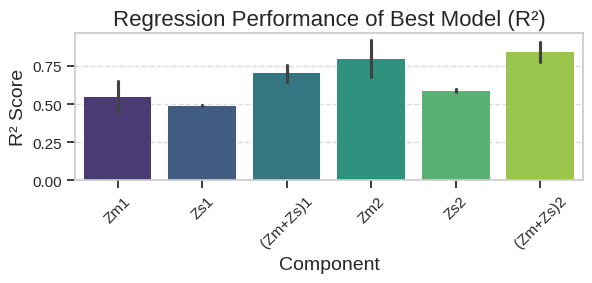

/tmp/ipykernel_714770/317152896.py:181: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(x='name', y='accuracy', data=best_cls, ci='sd', palette='viridis')
/tmp/ipykernel_714770/317152896.py:181: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='name', y='accuracy', data=best_cls, ci='sd', palette='viridis')


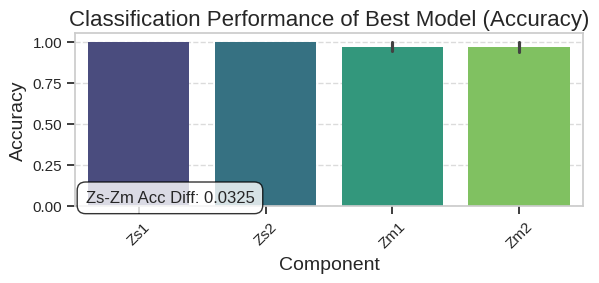

/tmp/ipykernel_714770/317152896.py:200: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(x='name', y='value', data=best_corr, ci='sd', palette='viridis')
/tmp/ipykernel_714770/317152896.py:200: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='name', y='value', data=best_corr, ci='sd', palette='viridis')


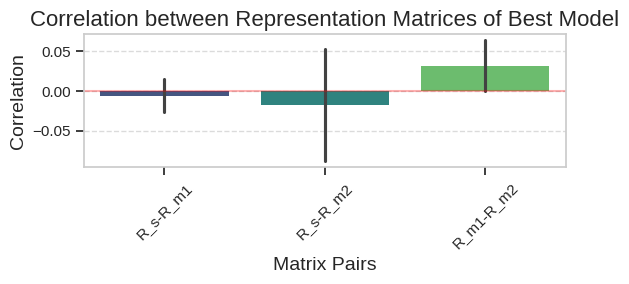

/tmp/ipykernel_714770/317152896.py:212: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(x='name', y='value', data=best_rank, ci='sd', palette='viridis')
/tmp/ipykernel_714770/317152896.py:212: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='name', y='value', data=best_rank, ci='sd', palette='viridis')


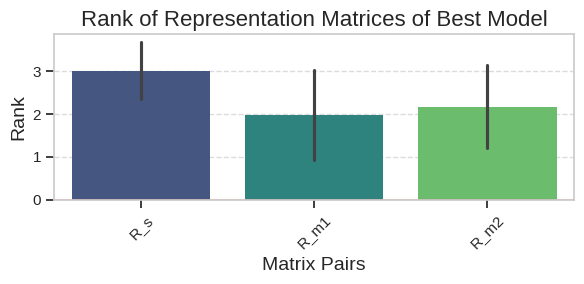

In [10]:
# Visualize the best model's performance
visualize_best_model(best_models.iloc[0], regression_df, classification_df, rank_df)

In [65]:
# Find best models for each criterion
regression_ranks = find_best_regression_models(regression_df)
classification_ranks = find_best_classification_models(classification_df)
correlation_ranks = find_best_correlation_models(rank_df)
accuracy_diff_ranks = find_best_accuracy_diff_models(classification_df)
rank_ranks = find_best_rank_models(rank_df)

restrictions = {
    'batch_size': [128],
    'learning_rate': [0.0001],
}
# Find overall best model
#best_models = find_best_overall_model(regression_ranks, classification_ranks, correlation_ranks, accuracy_diff_ranks)
best_models = find_best_overall_model(regression_ranks, classification_ranks, correlation_ranks, accuracy_diff_ranks, rank_ranks, include_rank=False, restrictions=restrictions)

# Display top 5 models for each criterion
print("\n### Top 5 Models for Regression Performance ((Zs+Zm))")
display(regression_ranks.head(5)[['batch_size', 'learning_rate', 'lr_annealing', 'weight_decay', 
                                 'specific_rank', 'shared_rank', 'r2_mean', 'rank']])

print("\n### Top 5 Models for Classification Performance (Zs)")
display(classification_ranks.head(5)[['batch_size', 'learning_rate', 'lr_annealing', 'weight_decay', 
                                     'specific_rank', 'shared_rank', 'accuracy', 'rank']])

print("\n### Top 5 Models for Low Correlation Between Rs")
display(correlation_ranks.head(5)[['batch_size', 'learning_rate', 'lr_annealing', 'weight_decay', 
                                  'specific_rank', 'shared_rank', 'abs_corr', 'rank']])

print("\n### Top 5 Models for Accuracy Difference (Zs - Zm)")
display(accuracy_diff_ranks.head(5)[['batch_size', 'learning_rate', 'lr_annealing', 'weight_decay', 
                                    'specific_rank', 'shared_rank', 'accuracy_diff', 'rank']])

print("\n### Top 5 Overall Models (Combined Ranking)")
#display(best_models.head(5)[['batch_size', 'learning_rate', 'lr_annealing', 'weight_decay', 
#                            'specific_rank', 'shared_rank', 'r2_mean', 'accuracy', 'abs_corr', 'accuracy_diff',
#                            'rank_reg', 'rank_cls', 'rank_corr', 'rank_acc_diff', 'combined_rank']])
display(best_models.head(5)[['batch_size', 'learning_rate', 'lr_annealing', 'weight_decay', 
                            'r2_mean', 'accuracy', 'abs_corr', 'accuracy_diff', 'matrix rank',
                            'rank_reg', 'rank_cls', 'rank_corr', 'rank_rank', 'rank_acc_diff', 'combined_rank']])

# Visualize the top model's performance
best_model = best_models.iloc[0]
print("\n### Best Model Configuration:")
for param in ['batch_size', 'learning_rate', 'lr_annealing', 'weight_decay', 'specific_rank', 'shared_rank']:
    print(f"{param}: {best_model[param]}")

print(f"\nPerformance metrics:")
print(f"Regression R² ((Zs+Zm)): {best_model['r2_mean']:.4f}")
print(f"Classification Accuracy (Zs): {best_model['accuracy']:.4f}")
print(f"Mean Correlation between Rs: {best_model['abs_corr']:.4f}")
print(f"Accuracy Difference (Zs - Zm): {best_model['accuracy_diff']:.4f}")
print(f"Matrix Rank: {best_model['matrix rank']:.4f}")


### Top 5 Models for Regression Performance ((Zs+Zm))


,batch_size,learning_rate,lr_annealing,weight_decay,specific_rank,shared_rank,r2_mean,rank
36,512,0.00001,constant,0.0000,4,4,0.929934,1.0
39,512,0.00001,cosine,0.0001,4,4,0.884924,2.0
38,512,0.00001,cosine,0.0000,4,4,0.863212,3.0
27,256,0.00001,cosine,0.0001,4,4,0.853918,4.0
37,512,0.00001,constant,0.0001,4,4,0.852971,5.0



### Top 5 Models for Classification Performance (Zs)


,batch_size,learning_rate,lr_annealing,weight_decay,specific_rank,shared_rank,accuracy,rank
5,64,0.0001,constant,0.0001,4,4,1.0,3.5
11,64,0.0010,cosine,0.0001,4,4,1.0,3.5
21,128,0.0010,constant,0.0001,4,4,1.0,3.5
23,128,0.0010,cosine,0.0001,4,4,1.0,3.5
46,512,0.0010,cosine,0.0000,4,4,1.0,3.5



### Top 5 Models for Low Correlation Between Rs


...


### Top 5 Models for Accuracy Difference (Zs - Zm)


,batch_size,learning_rate,lr_annealing,weight_decay,specific_rank,shared_rank,accuracy_diff,rank
21,128,0.0010,constant,0.0001,4,4,0.089167,1.0
23,128,0.0010,cosine,0.0001,4,4,0.085556,2.0
33,256,0.0010,constant,0.0001,4,4,0.078611,3.0
31,256,0.0001,cosine,0.0001,4,4,0.075278,4.0
7,64,0.0001,cosine,0.0001,4,4,0.071111,5.0



### Top 5 Overall Models (Combined Ranking)


,batch_size,learning_rate,lr_annealing,weight_decay,r2_mean,accuracy,abs_corr,accuracy_diff,matrix rank,rank_reg,rank_cls,rank_corr,rank_rank,rank_acc_diff,combined_rank
3,128,0.0001,constant,0.0000,0.697455,0.998889,0.042455,0.050833,2.111111,34.0,22.0,7.0,25.0,11.0,74.0
0,128,0.0001,constant,0.0001,0.767975,0.999444,0.070596,0.031389,2.000000,15.0,20.0,21.0,17.0,20.5,76.5
1,128,0.0001,cosine,0.0000,0.758263,0.998611,0.040187,0.024167,2.000000,19.0,27.0,4.0,17.0,27.0,77.0
2,128,0.0001,cosine,0.0001,0.731072,0.999444,0.061034,0.043056,2.111111,28.0,18.5,19.0,25.0,13.0,78.5



### Best Model Configuration:
batch_size: 128
learning_rate: 0.0001
lr_annealing: constant
weight_decay: 0.0
specific_rank: 4
shared_rank: 4

Performance metrics:
Regression R² ((Zs+Zm)): 0.6975
Classification Accuracy (Zs): 0.9989
Mean Correlation between Rs: 0.0425
Accuracy Difference (Zs - Zm): 0.0508
Matrix Rank: 2.1111


### Visualize the best models

/tmp/ipykernel_695823/317152896.py:170: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(x='name', y='r2_mean', data=best_reg, ci='sd', palette='viridis')
/tmp/ipykernel_695823/317152896.py:170: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='name', y='r2_mean', data=best_reg, ci='sd', palette='viridis')


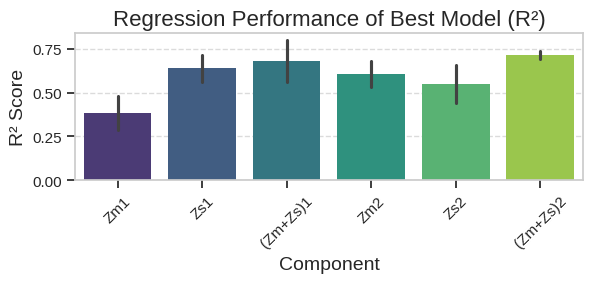

/tmp/ipykernel_695823/317152896.py:181: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(x='name', y='accuracy', data=best_cls, ci='sd', palette='viridis')
/tmp/ipykernel_695823/317152896.py:181: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='name', y='accuracy', data=best_cls, ci='sd', palette='viridis')


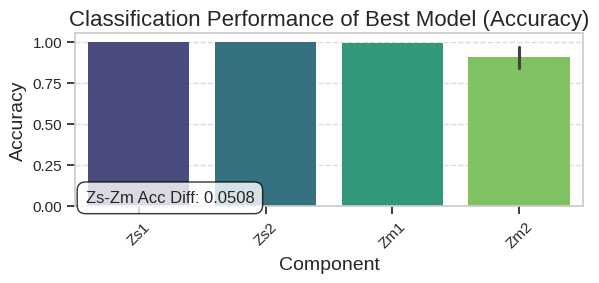

/tmp/ipykernel_695823/317152896.py:200: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(x='name', y='value', data=best_corr, ci='sd', palette='viridis')
/tmp/ipykernel_695823/317152896.py:200: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='name', y='value', data=best_corr, ci='sd', palette='viridis')


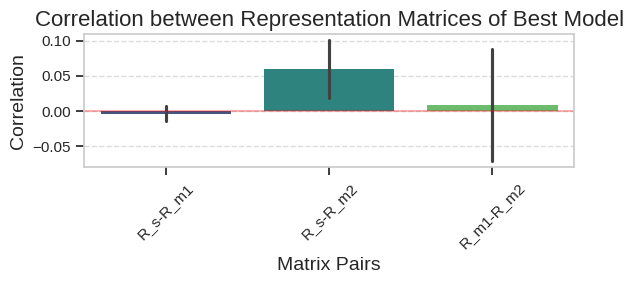

/tmp/ipykernel_695823/317152896.py:212: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(x='name', y='value', data=best_rank, ci='sd', palette='viridis')
/tmp/ipykernel_695823/317152896.py:212: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='name', y='value', data=best_rank, ci='sd', palette='viridis')


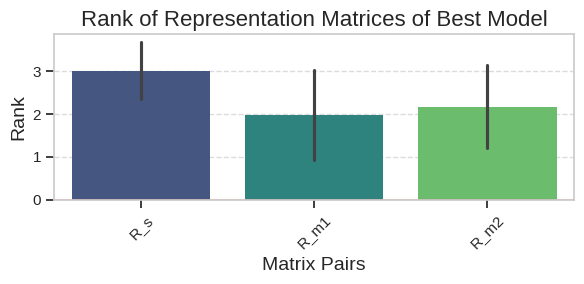

In [66]:
# Visualize the best model's performance
visualize_best_model(best_models.iloc[0], regression_df, classification_df, rank_df)

/tmp/ipykernel_695823/317152896.py:170: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(x='name', y='r2_mean', data=best_reg, ci='sd', palette='viridis')
/tmp/ipykernel_695823/317152896.py:170: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='name', y='r2_mean', data=best_reg, ci='sd', palette='viridis')


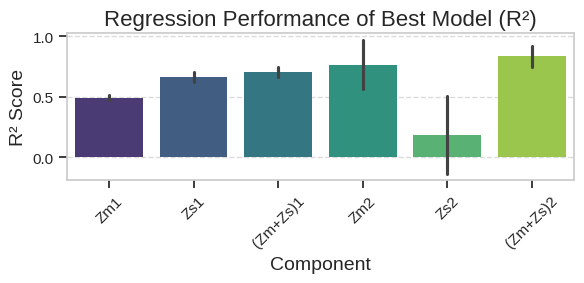

/tmp/ipykernel_695823/317152896.py:181: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(x='name', y='accuracy', data=best_cls, ci='sd', palette='viridis')
/tmp/ipykernel_695823/317152896.py:181: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='name', y='accuracy', data=best_cls, ci='sd', palette='viridis')


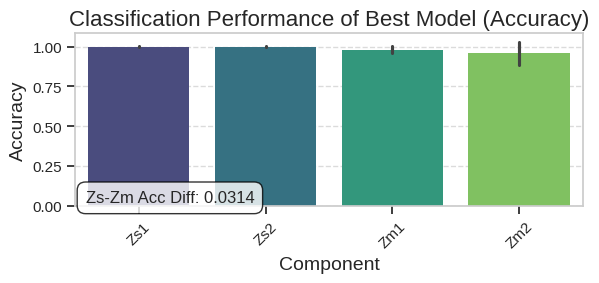

/tmp/ipykernel_695823/317152896.py:200: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(x='name', y='value', data=best_corr, ci='sd', palette='viridis')
/tmp/ipykernel_695823/317152896.py:200: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='name', y='value', data=best_corr, ci='sd', palette='viridis')


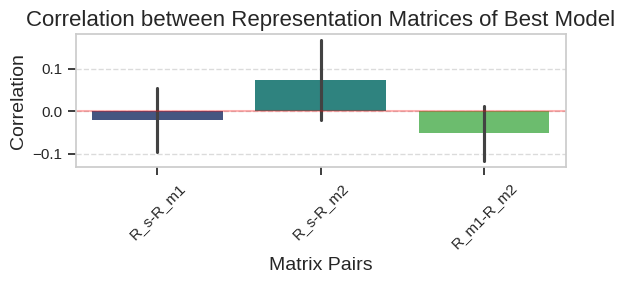

/tmp/ipykernel_695823/317152896.py:212: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(x='name', y='value', data=best_rank, ci='sd', palette='viridis')
/tmp/ipykernel_695823/317152896.py:212: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='name', y='value', data=best_rank, ci='sd', palette='viridis')


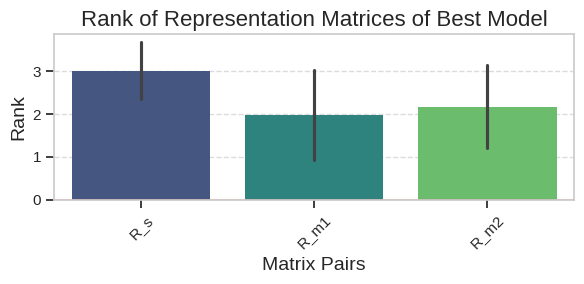

In [67]:
# Visualize the best model's performance
visualize_best_model(best_models.iloc[1], regression_df, classification_df, rank_df)

/tmp/ipykernel_695823/317152896.py:170: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(x='name', y='r2_mean', data=best_reg, ci='sd', palette='viridis')
/tmp/ipykernel_695823/317152896.py:170: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='name', y='r2_mean', data=best_reg, ci='sd', palette='viridis')


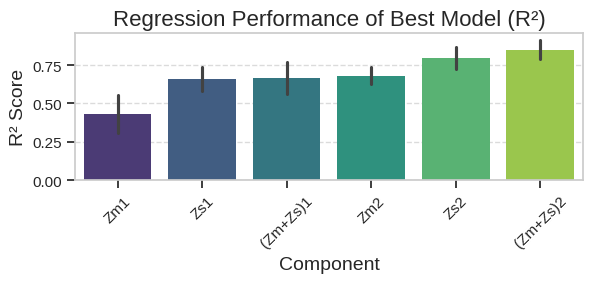

/tmp/ipykernel_695823/317152896.py:181: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(x='name', y='accuracy', data=best_cls, ci='sd', palette='viridis')
/tmp/ipykernel_695823/317152896.py:181: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='name', y='accuracy', data=best_cls, ci='sd', palette='viridis')


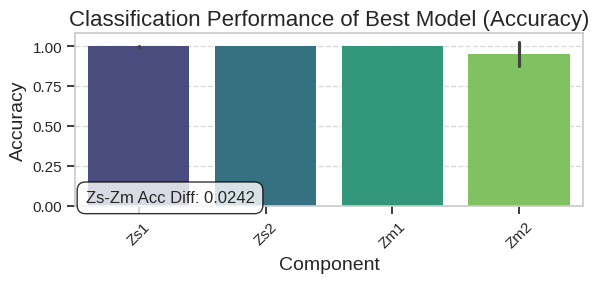

/tmp/ipykernel_695823/317152896.py:200: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(x='name', y='value', data=best_corr, ci='sd', palette='viridis')
/tmp/ipykernel_695823/317152896.py:200: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='name', y='value', data=best_corr, ci='sd', palette='viridis')


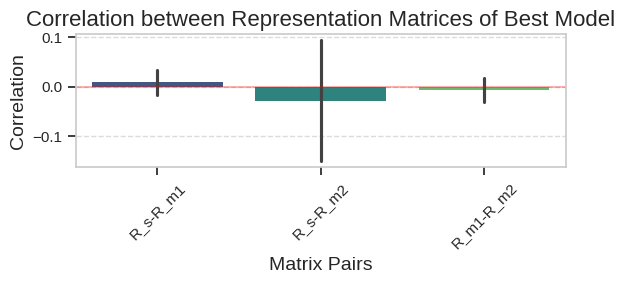

/tmp/ipykernel_695823/317152896.py:212: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(x='name', y='value', data=best_rank, ci='sd', palette='viridis')
/tmp/ipykernel_695823/317152896.py:212: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='name', y='value', data=best_rank, ci='sd', palette='viridis')


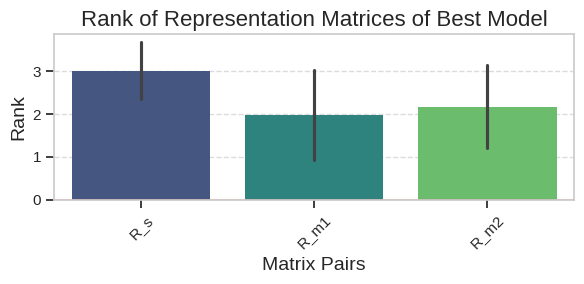

In [68]:
# Visualize the best model's performance
visualize_best_model(best_models.iloc[2], regression_df, classification_df, rank_df)

/tmp/ipykernel_695823/317152896.py:170: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(x='name', y='r2_mean', data=best_reg, ci='sd', palette='viridis')
/tmp/ipykernel_695823/317152896.py:170: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='name', y='r2_mean', data=best_reg, ci='sd', palette='viridis')


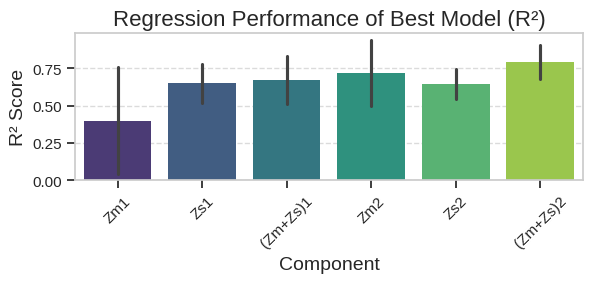

/tmp/ipykernel_695823/317152896.py:181: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(x='name', y='accuracy', data=best_cls, ci='sd', palette='viridis')
/tmp/ipykernel_695823/317152896.py:181: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='name', y='accuracy', data=best_cls, ci='sd', palette='viridis')


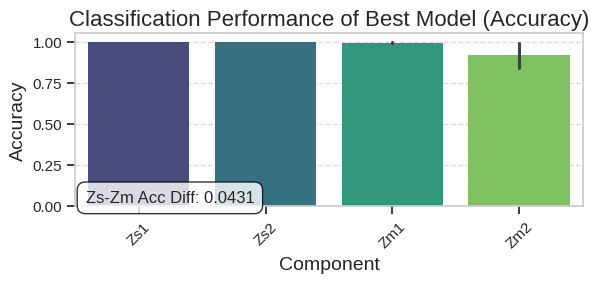

/tmp/ipykernel_695823/317152896.py:200: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(x='name', y='value', data=best_corr, ci='sd', palette='viridis')
/tmp/ipykernel_695823/317152896.py:200: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='name', y='value', data=best_corr, ci='sd', palette='viridis')


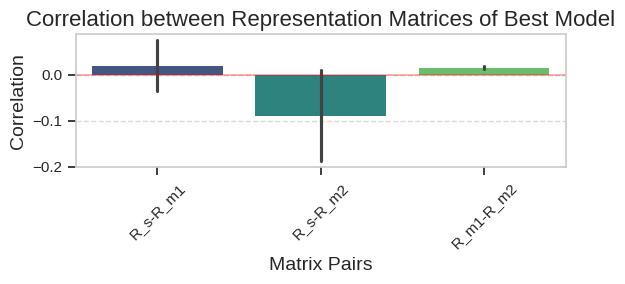

/tmp/ipykernel_695823/317152896.py:212: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(x='name', y='value', data=best_rank, ci='sd', palette='viridis')
/tmp/ipykernel_695823/317152896.py:212: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='name', y='value', data=best_rank, ci='sd', palette='viridis')


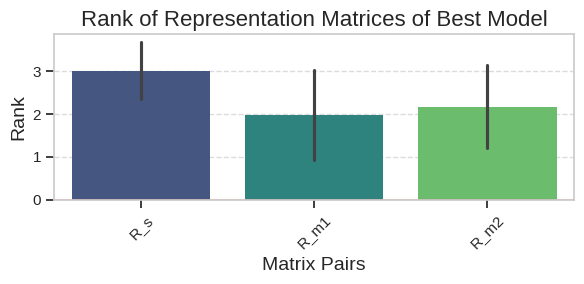

In [69]:
# Visualize the best model's performance
visualize_best_model(best_models.iloc[3], regression_df, classification_df, rank_df)

## 6. Conclusions

Based on our analysis, we have identified the optimal hyperparameter configuration that balances:

1. Strong regression performance on the combined (Zs+Zm) representations
2. High classification accuracy on the shared (Zs) representations
3. Low correlation between representation matrices (Rs, Rm1, Rm2)
4. Large difference between classification accuracy of Zs and Zm representations

This configuration provides the best trade-off between performance and representation quality across tasks, while ensuring that the shared representations capture discriminative information better than modality-specific representations.